In [1]:
import pandas as pd
df = pd.read_csv('ecommerce_sales.csv')
df

,order_id,customer_id,order_date,product_category,product_id,quantity,unit_price,payment_method,region,total_price
0,b0b64fb9-0495-4b00-ac7f-cfb66e66e428,cbd2a440-44d6-45a8-b162-3820beea740e,08-12-2023,Beauty,ce85c737-b5c5-4006-aa5d-278138ca41c1,3,414.62,Debit Card,South,1243.86
1,6323978a-9750-40bf-9277-3e261087b08b,22d03603-f4c2-49b0-88c0-81538d840be3,22-07-2024,Electronics,0f361ded-7c07-4c51-b76d-dcc22919282c,4,383.44,Net Banking,Central,1533.76
2,e21b001a-b5d5-4341-a43d-2a34b66e89f7,fb439d63-675f-450d-b6e1-cc948c8f1bcd,01-01-2024,Electronics,a6948602-4172-40c2-ba50-1c99ab7ddf30,1,288.90,Debit Card,North,288.90
3,4c3b041f-0bb1-4f39-9952-8db0cc67910f,1d2a2dee-f7da-469a-b415-698676a3999c,31-07-2023,Beauty,95c3a574-b17e-4265-a812-e985003506db,3,478.24,Credit Card,North,1434.72
4,9a1b2de0-3244-43cd-b924-42d7ffba8765,d6a42319-f09c-4321-85a1-9bb7fbaafffd,17-04-2023,Books,803b6c9e-9985-40bd-9fd5-b8ee79ef4d39,3,104.23,Wallet,East,312.69
...,...,...,...,...,...,...,...,...,...,...
4995,e350a915-b507-4ef5-8685-d02d31060f8a,9c5cea20-9bce-4b38-82ac-62520e819fac,05-01-2023,Books,93e15339-b846-4715-97d2-1bd407c099f9,1,43.78,Credit Card,North,43.78
4996,4bac3797-4c34-42df-9709-0345c9076562,713719c8-75c1-4aa5-9aa4-bc1bb987589d,15-08-2024,Sports,baac35ca-b804-48c5-aabc-ab0f362e62e1,2,40.92,Wallet,North,81.84
4997,0b738deb-e07a-4024-9ae8-07d8c45a2131,ce4662d4-d76c-45d5-a3cd-8f521788a5c0,28-10-2023,Electronics,0ebd63c6-51cd-42bb-ba1a-2cd6a789f4f8,3,425.91,Wallet,North,1277.73
4998,fd25db39-0098-41af-a017-d25f1c0f833f,f53f6bc2-4edd-425f-92a3-7960209a810e,25-09-2024,Electronics,c2977d39-f695-40dc-9331-30e8536d152a,2,110.36,Wallet,South,220.72


In [2]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_date',
 'product_category',
 'product_id',
 'quantity',
 'unit_price',
 'payment_method',
 'region',
 'total_price']

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   object 
 1   customer_id       5000 non-null   object 
 2   order_date        5000 non-null   object 
 3   product_category  5000 non-null   object 
 4   product_id        5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   payment_method    5000 non-null   object 
 8   region            5000 non-null   object 
 9   total_price       5000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 254.0+ KB


In [4]:
df.describe().round()

,quantity,unit_price,total_price
count,5000.0,5000.0,5000.0
mean,2.0,250.0,619.0
std,1.0,143.0,479.0
min,1.0,5.0,5.0
25%,1.0,127.0,243.0
50%,2.0,246.0,474.0
75%,4.0,372.0,907.0
max,4.0,500.0,1999.0


In [5]:
df.isnull().sum()

order_id            0
customer_id         0
order_date          0
product_category    0
product_id          0
quantity            0
unit_price          0
payment_method      0
region              0
total_price         0
dtype: int64

In [6]:
df[df.duplicated()]

,order_id,customer_id,order_date,product_category,product_id,quantity,unit_price,payment_method,region,total_price


In [215]:
for col in df.columns:
    if df[col].nunique()<30:
        print(df[col].value_counts().sort_values())
        print('-'*50)
    else : 
        print(col)
        print(df[col].nunique())
        print('-'*50)

order_id
5000
--------------------------------------------------
customer_id
5000
--------------------------------------------------
order_date
729
--------------------------------------------------
product_category
Clothing          689
Electronics       695
Toys              705
Books             716
Sports            719
Home & Kitchen    728
Beauty            748
Name: count, dtype: int64
--------------------------------------------------
product_id
5000
--------------------------------------------------
quantity
3    1209
2    1240
4    1256
1    1295
Name: count, dtype: int64
--------------------------------------------------
unit_price
4759
--------------------------------------------------
payment_method
Wallet               981
Credit Card          982
Debit Card           990
Cash on Delivery    1014
Net Banking         1033
Name: count, dtype: int64
--------------------------------------------------
region
Central     953
East        977
South      1004
West       1018
North

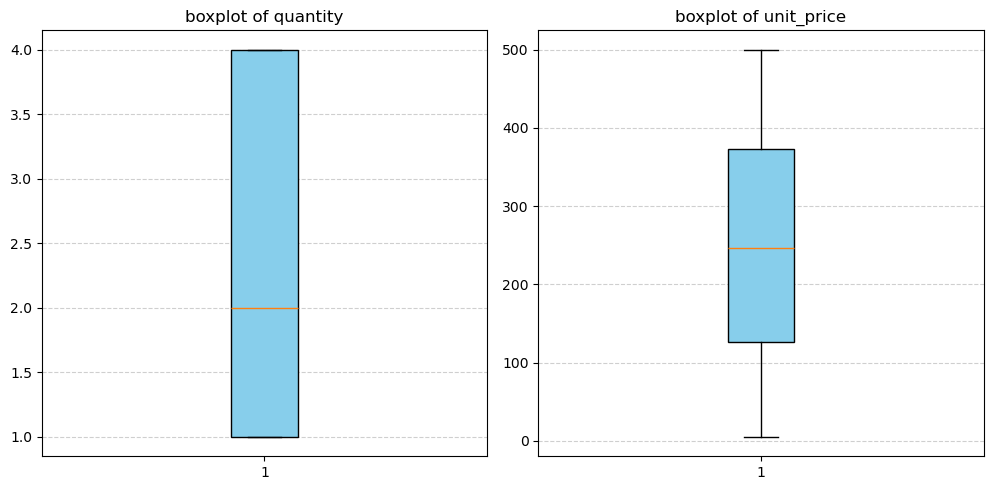

(5000, 10)

In [8]:
import matplotlib.pyplot as plt

cols = ['quantity', 'unit_price']
plt.figure(figsize=(15, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df[col], vert=True, patch_artist=True,
                boxprops=dict(facecolor='skyblue'))
    plt.title(f'boxplot of {col}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

from scipy import stats
stats.zscore(df[['quantity','unit_price']])

import numpy as np
z_scores=np.abs(stats.zscore(df[['quantity','unit_price']]))
df_clean=df[~(z_scores>3).any(axis=1)]
df_clean.shape

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [10]:
df['expected_total']=df['quantity']*df['unit_price']

In [92]:
###Validate and recalculate total_price###

# Step 1 - Create comparison column
df['is_match'] = df['total_price'].round(2) == df['expected_total'].round(2)

# Step 2 - Summary Count
print("=== SUMMARY ===")
print(df['is_match'].value_counts())

# Step 3 - Total rows
total        = len(df)
equal_rows   = df['is_match'].sum()
unequal_rows = total - equal_rows

# Step 4 - Percentage
print(f"\nMatch Rate     : {equal_rows/total*100:.2f}%")
print(f"Mismatch Rate  : {unequal_rows/total*100:.2f}%")

# Step 5 - View mismatched rows
print("\n=== MISMATCHED ROWS ===")
print(df[df['is_match'] == False][['total_price', 'expected_total', 'is_match']])


=== SUMMARY ===
is_match
True    5000
Name: count, dtype: int64

Match Rate     : 100.00%
Mismatch Rate  : 0.00%

=== MISMATCHED ROWS ===
Empty DataFrame
Columns: [total_price, expected_total, is_match]
Index: []


===Total Sales Over Time===
3094157.66

=== DAILY TOTAL SALES ===
    order_date  Total_Sales  Cumm_Sales
0   2023-01-01      3862.94     3862.94
1   2023-01-02      3456.24     7319.18
2   2023-01-03      4537.70    11856.88
3   2023-01-04      7326.12    19183.00
4   2023-01-05      4851.41    24034.41
..         ...          ...         ...
724 2024-12-26      2790.04  3081397.37
725 2024-12-27      8521.93  3089919.30
726 2024-12-28      1134.13  3091053.43
727 2024-12-29      2058.19  3093111.62
728 2024-12-30      1046.04  3094157.66

[729 rows x 3 columns]

=== MONTHLY SALES TREND ===
    year  month  Total_Sales  Total_Orders  Cumm_Sales   period
0   2023      1    126685.35           202   126685.35  2023-01
1   2023      2    127206.81           208   253892.16  2023-02
2   2023      3    115417.93           187   369310.09  2023-03
3   2023      4    149865.91           238   519176.00  2023-04
4   2023      5    117204.54           191   636380.54  2023-05
5   2023      6  

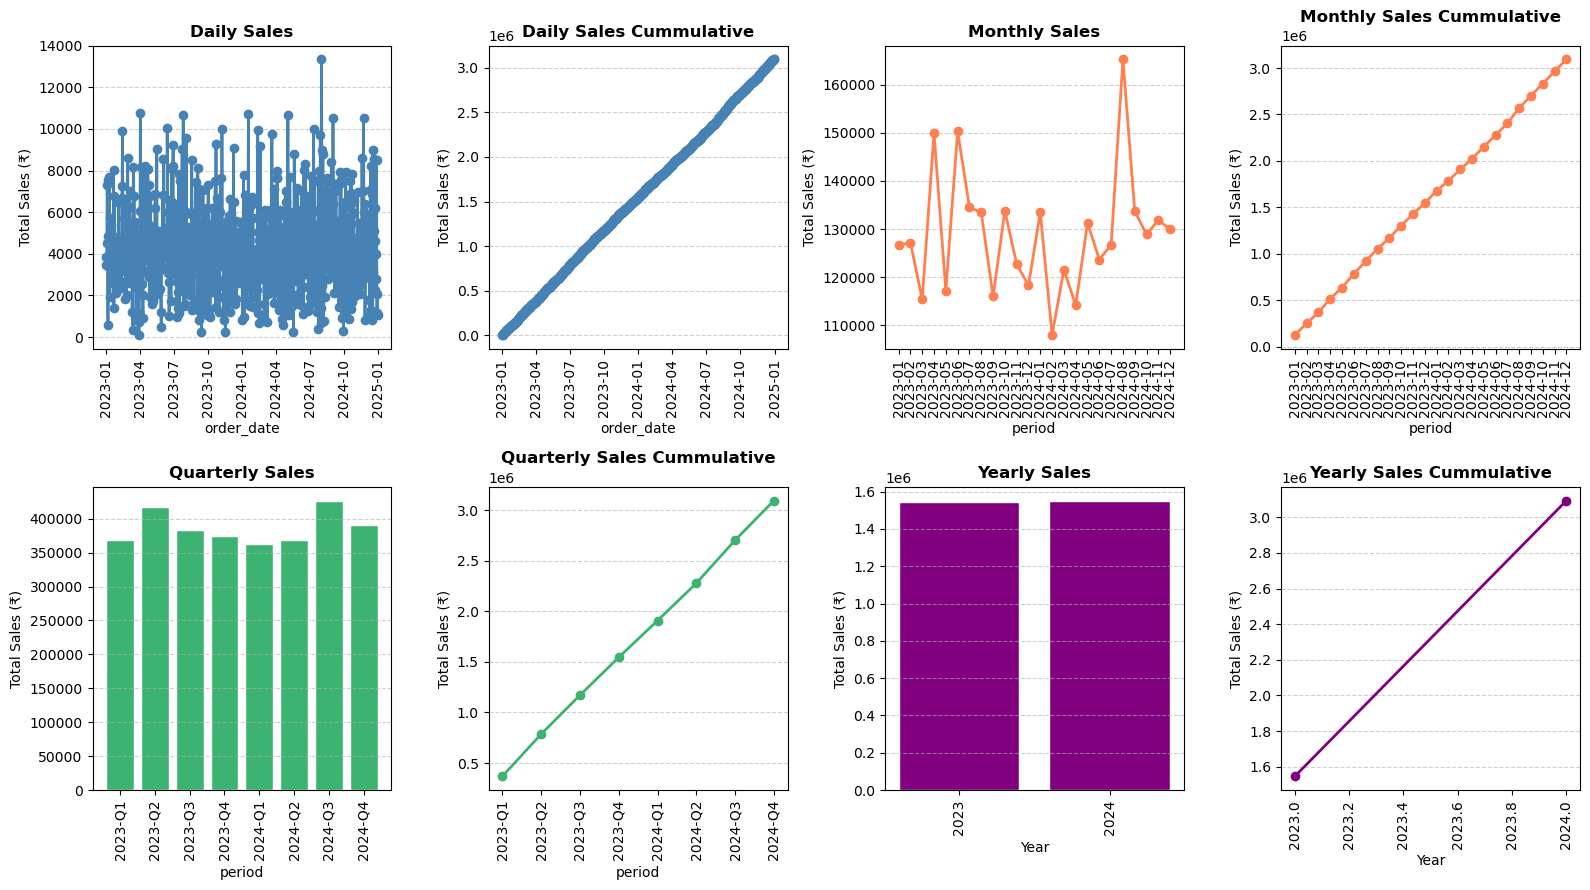

In [216]:
###Total sales over time.

print('===Total Sales Over Time===')
print(df['total_price'].sum().round(2))

# extract date parts
df['year']    = df['order_date'].dt.year
df['month']   = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter

daily_sales=df.groupby('order_date')['total_price'].sum().reset_index().sort_values(['order_date'])
daily_sales.columns=['order_date','Total_Sales']
daily_sales['Cumm_Sales']=daily_sales['Total_Sales'].cumsum()

print("\n=== DAILY TOTAL SALES ===")
print(daily_sales)

#####Monthly/quarterly/yearly trends#####
# --- Monthly Trend ---
monthly_sales = df.groupby(['year', 'month']).agg(
    Total_Sales  = ('total_price', 'sum'),
    Total_Orders = ('total_price', 'count')
).reset_index().sort_values(['year', 'month'])

monthly_sales['Cumm_Sales']=monthly_sales['Total_Sales'].cumsum()

# Create a string column like "2023-01" to ensure proper sorting
monthly_sales['period'] = monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str).str.zfill(2)

print("\n=== MONTHLY SALES TREND ===")
print(monthly_sales)


# --- Quarterly Trend ---
quarterly_sales = df.groupby(['year', 'quarter']).agg(
    Total_Sales  = ('total_price', 'sum'),
    Total_Orders = ('total_price', 'count')
).reset_index().sort_values(['year', 'quarter'])

quarterly_sales['Cumm_Sales']=quarterly_sales['Total_Sales'].cumsum()

quarterly_sales['Quarter'] = 'Q' + quarterly_sales['quarter'].astype(str)

# Create a string column like "2023-01" to ensure proper sorting
quarterly_sales['period'] = quarterly_sales['year'].astype(str) + '-' + quarterly_sales['Quarter'].astype(str)

print("\n=== QUARTERLY SALES ===")
print(quarterly_sales)

# --- Yearly Trend ---

yearly_sales = df.groupby('year')['total_price'].sum().reset_index()
yearly_sales.columns = ['Year', 'Total_Sales']
yearly_sales['Cumm_Sales']=yearly_sales['Total_Sales'].cumsum()
print("\n=== YEARLY SALES ===")
print(yearly_sales)

###summary table###
print("="*45)
print("       TOTAL SALES OVER TIME SUMMARY")
print("="*45)

print(f"\n Overall Total Sales : ₹{df['total_price'].sum():,.2f}")
print(f" First Order Date    : {df['order_date'].min().date()}")
print(f" Last Order Date     : {df['order_date'].max().date()}")
print(f" Total Days          : {(df['order_date'].max() - df['order_date'].min()).days}")
print(f" Avg Daily Sales     : ₹{df.groupby('order_date')['total_price'].sum().mean():,.2f}")
print(f" Best Day            : {df.groupby('order_date')['total_price'].sum().idxmax().date()}")
print(f" Worst Day           : {df.groupby('order_date')['total_price'].sum().idxmin().date()}")
print(f" Best Year           : {yearly_sales.loc[yearly_sales['Total_Sales'].idxmax(), 'Year']}")


##########OPTIONAL#################
import matplotlib.pyplot as plt

# define all sales data with chart settings
sales_charts = [
    {'data': daily_sales,     'x': 'order_date', 'y': 'Total_Sales', 
     'title': 'Daily Sales',     'color': 'steelblue',    'chart': 'line'},
    {'data': daily_sales,     'x': 'order_date', 'y': 'Cumm_Sales', 
     'title': 'Daily Sales Cummulative',     'color': 'steelblue',    'chart': 'line'},
    
    {'data': monthly_sales,   'x': 'period',  'y': 'Total_Sales', 
     'title': 'Monthly Sales',   'color': 'coral',        'chart': 'line'},
    {'data': monthly_sales,   'x': 'period',  'y': 'Cumm_Sales', 
     'title': 'Monthly Sales Cummulative',   'color': 'coral',        'chart': 'line'},
    
    {'data': quarterly_sales, 'x': 'period',     'y': 'Total_Sales', 
     'title': 'Quarterly Sales', 'color': 'mediumseagreen','chart': 'bar'},
    {'data': quarterly_sales, 'x': 'period',     'y': 'Cumm_Sales', 
     'title': 'Quarterly Sales Cummulative', 'color': 'mediumseagreen','chart': 'line'},
    
    {'data': yearly_sales,    'x': 'Year',        'y': 'Total_Sales', 
     'title': 'Yearly Sales',    'color': 'purple',       'chart': 'bar'},
    {'data': yearly_sales,    'x': 'Year',        'y': 'Cumm_Sales', 
     'title': 'Yearly Sales Cummulative',    'color': 'purple',       'chart': 'line'}
]

import matplotlib.pyplot as plt

# 1. Create a 4x2 grid of subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

# 2. Flatten the axes array for easier indexing (from 4x2 matrix to 8x1 list)
axes_flat = axes.flatten()

# 3. Loop through your sales_charts and assign each to an axis
for i, chart in enumerate(sales_charts):
    ax = axes_flat[i]
    
    if chart['chart'] == 'line':
        ax.plot(chart['data'][chart['x']], chart['data'][chart['y']], 
                color=chart['color'], marker='o', linewidth=2)
    else:
        ax.bar(chart['data'][chart['x']].astype(str), chart['data'][chart['y']], 
               color=chart['color'], edgecolor='white')
    
    ax.set_title(chart['title'], fontsize=12, fontweight='bold')
    ax.set_xlabel(chart['x'])
    ax.set_ylabel('Total Sales (₹)')
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Clean up layout and remove any empty subplots if you had fewer than 8
plt.tight_layout()
plt.show()

===SALES BY PRODUCT CATEGORY===
  product_category  Total_Sales  Total_Orders  Total_Quantity
5           Sports    473482.15           719            1813
0           Beauty    460978.54           748            1874
3      Electronics    448010.81           695            1761
1            Books    441302.55           716            1764
4   Home & Kitchen    438849.82           728            1820
6             Toys    434620.78           705            1752
2         Clothing    396913.01           689            1642

Overall Average Order Value: ₹618.83


===AVERAGE ORDER VALUE===
  product_category  Avg_Order_Value
5           Sports       658.528720
3      Electronics       644.619871
6             Toys       616.483376
1            Books       616.344344
0           Beauty       616.281471
4   Home & Kitchen       602.815687
2         Clothing       576.071132

=== TOP 10 PRODUCTS BY REVENUE ===
  product_category  Total_Sales  Total_Orders  Total_Quantity
5           Sports  

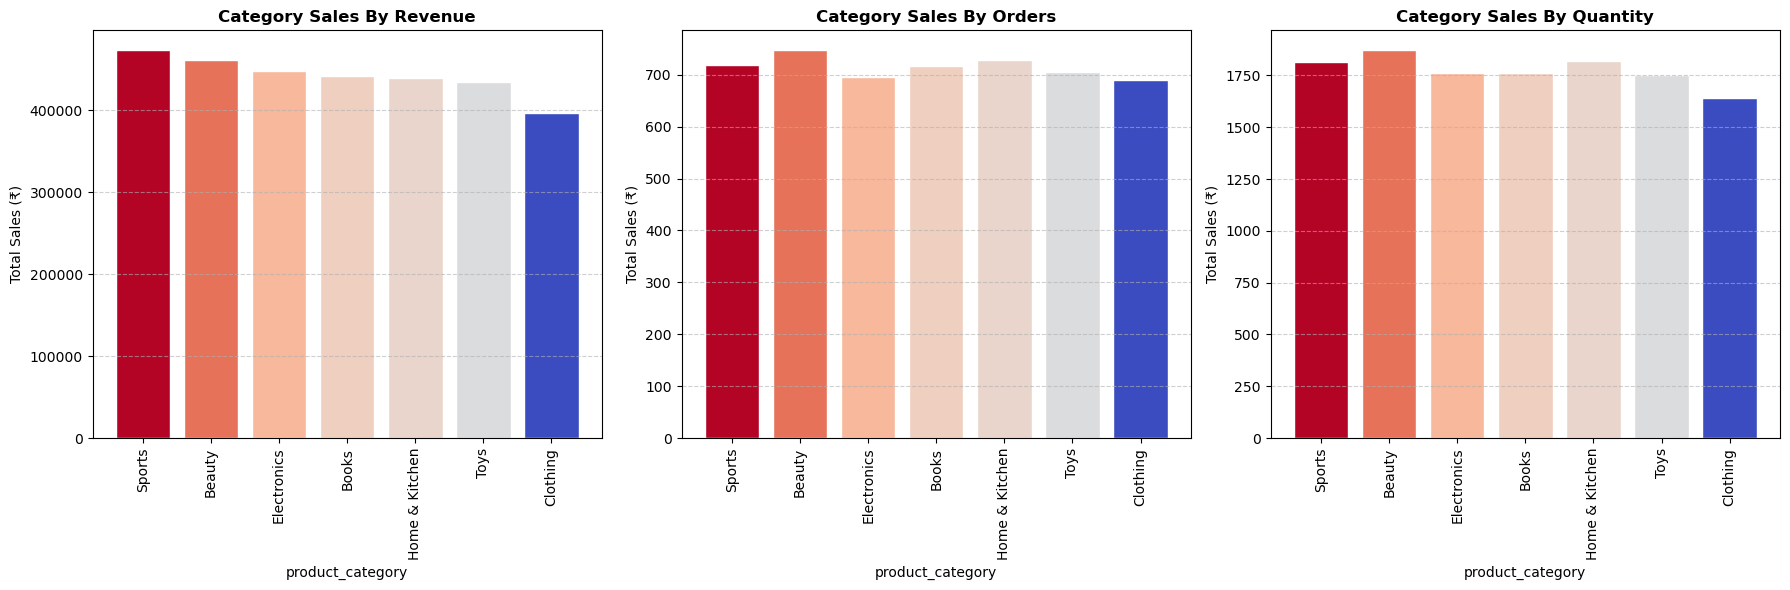

In [245]:
##### Sales By Product Category #####
category_sales = df.groupby('product_category').agg(
    Total_Sales    = ('total_price', 'sum'),
    Total_Orders   = ('total_price', 'count'),
    Total_Quantity = ('quantity', 'sum') ).reset_index()

# sort by highest sales
category_sales = category_sales.sort_values('Total_Sales', ascending=False)
print('===SALES BY PRODUCT CATEGORY===')
print(category_sales)



##### overall average order value  #####
aov = df['total_price'].mean()
print(f"\nOverall Average Order Value: ₹{aov:.2f}\n")

    # average order value by category
aov_by_category = df.groupby('product_category')['total_price'].mean().reset_index()
aov_by_category.columns = ['product_category', 'Avg_Order_Value']
aov_by_category = aov_by_category.sort_values('Avg_Order_Value', ascending=False)
print('\n===AVERAGE ORDER VALUE===')
print(aov_by_category)

#####Identify best-selling products#####
    # by total revenue
print("\n=== TOP 10 PRODUCTS BY REVENUE ===")
print(category_sales.head(10))

    # by quantity sold
best_by_quantity = df.groupby('product_category')['quantity'].sum()\
                     .reset_index()\
                     .sort_values('quantity', ascending=False)

print("\n=== TOP 10 PRODUCTS BY QUANTITY ===")
print(best_by_quantity.head(10))

import matplotlib.pyplot as plt

# define all sales data with chart settings
sales_charts = [
    {'data': category_sales,     'x': 'product_category', 'y': 'Total_Sales', 
     'title': 'Category Sales By Revenue',     'color': colors,    'chart': 'bar'},

    {'data': category_sales,     'x': 'product_category', 'y': 'Total_Orders', 
     'title': 'Category Sales By Orders',     'color': colors,    'chart': 'bar'},
    
    {'data': category_sales,     'x': 'product_category', 'y': 'Total_Quantity', 
     'title': 'Category Sales By Quantity',     'color': colors,    'chart': 'bar'}
]

    

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Prepare the gradient colors
values = category_sales['Total_Sales']
norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
cmap = cm.coolwarm
colors = [cmap(norm(val)) for val in values]

# 1. Create a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 2. Loop through your sales_charts and assign each to an axis
for i, chart in enumerate(sales_charts):
    ax = axes[i]

    ax.bar(chart['data'][chart['x']].astype(str), chart['data'][chart['y']],color=chart['color'], edgecolor='white')
    ax.set_title(chart['title'], fontsize=12, fontweight='bold')
    ax.set_xlabel(chart['x'])
    ax.set_ylabel('Total Sales (₹)')
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
   
# 3. Clean up layout and remove any empty subplots
plt.tight_layout()
plt.show()




=== YEARLY GROWTH RATE ===
   Year  Total_Sales  YoY_Growth_%
0  2023   1545516.68           NaN
1  2024   1548640.98      0.202152

=== MONTHLY GROWTH RATE ===
    year  month   period  Total_Sales  MoM_Growth_%
0   2023      1  2023-01    126685.35           NaN
1   2023      2  2023-02    127206.81      0.411618
2   2023      3  2023-03    115417.93     -9.267491
3   2023      4  2023-04    149865.91     29.846299
4   2023      5  2023-05    117204.54    -21.793729
5   2023      6  2023-06    150277.12     28.217832
6   2023      7  2023-07    134530.10    -10.478654
7   2023      8  2023-08    133452.11     -0.801300
8   2023      9  2023-09    116023.66    -13.059704
9   2023     10  2023-10    133800.04     15.321340
10  2023     11  2023-11    122733.84     -8.270700
11  2023     12  2023-12    118319.27     -3.596865
12  2024      1  2024-01    133521.94     12.848854
13  2024      2  2024-02    108023.40    -19.096891
14  2024      3  2024-03    121578.47     12.548272
15  20

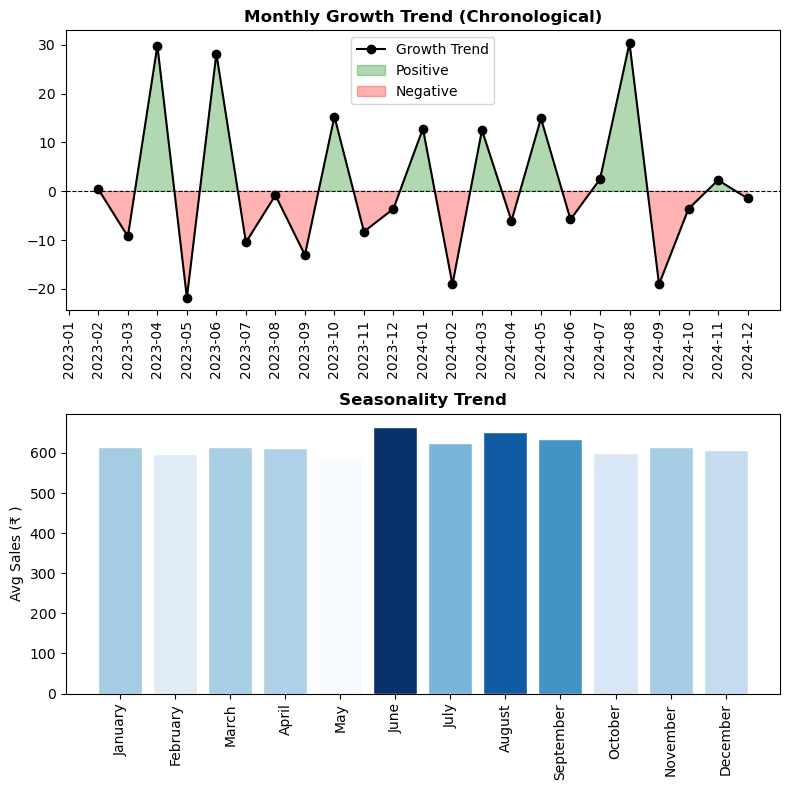

         COMPLETE SALES SUMMARY REPORT

 Total Revenue       : ₹3,094,157.66
 Total Orders        : 5000
 Avg Order Value     : ₹618.83
 Total Products Sold : 12,426
 Best Category       : Sports
 Best Month          : January


In [230]:
######Growth rates and seasonality######
# yearly growth rate
yearly_sales['YoY_Growth_%'] = yearly_sales['Total_Sales'].pct_change() * 100
print("\n=== YEARLY GROWTH RATE ===")
print(yearly_sales[['Year', 'Total_Sales', 'YoY_Growth_%']])

# monthly growth rate
monthly_sales['MoM_Growth_%'] = monthly_sales['Total_Sales'].pct_change() * 100
monthly_sales['period'] = monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str).str.zfill(2)

print("\n=== MONTHLY GROWTH RATE ===")
print(monthly_sales[['year', 'month','period', 'Total_Sales', 'MoM_Growth_%']])

# average sales per month across all years (seasonality)
seasonality = df.groupby('month')['total_price'].mean().reset_index()
seasonality.columns = ['month', 'Avg_Monthly_Sales']
seasonality['month_name'] = pd.to_datetime(seasonality['month'], format='%m').dt.strftime('%B')
print("\n=== SEASONALITY (AVG SALES BY MONTH) ===")
print(seasonality.sort_values('Avg_Monthly_Sales', ascending=False))

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Prepare the gradient colors
values = seasonality['Avg_Monthly_Sales']
norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
cmap = cm.Blues
colors = [cmap(norm(val)) for val in values]

# 1. Setup the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# 2. Plot the main growth line (stays in order of 'period')
ax1.plot(monthly_sales['period'], monthly_sales['MoM_Growth_%'], 
         color='black', marker='o', linewidth=1.5, label='Growth Trend')

# 3. Add color fills based on positive/negative growth
# Fills area between the line and 0, color-coded by performance
ax1.fill_between(monthly_sales['period'], monthly_sales['MoM_Growth_%'], 0, 
                 where=(monthly_sales['MoM_Growth_%'] >= 0), 
                 interpolate=True, color='green', alpha=0.3, label='Positive')

ax1.fill_between(monthly_sales['period'], monthly_sales['MoM_Growth_%'], 0, 
                 where=(monthly_sales['MoM_Growth_%'] < 0), 
                 interpolate=True, color='red', alpha=0.3, label='Negative')

# 4. Formatting
ax1.set_title('Monthly Growth Trend (Chronological)', fontsize=12, fontweight='bold')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--') 
ax1.tick_params(axis='x', rotation=90)
ax1.legend()

# Chart 2 
ax2.bar(seasonality['month_name'], values , color=colors, edgecolor='white')
ax2.set_title('Seasonality Trend', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg Sales (₹ )')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

print("="*50)
print("         COMPLETE SALES SUMMARY REPORT")
print("="*50)

print(f"\n Total Revenue       : ₹{df['total_price'].sum():,.2f}")
print(f" Total Orders        : {len(df)}")
print(f" Avg Order Value     : ₹{df['total_price'].mean():,.2f}")
print(f" Total Products Sold : {df['quantity'].sum():,.0f}")
print(f" Best Category       : {category_sales.iloc[0]['product_category']}")
print(f" Best Month          : {seasonality.iloc[0]['month_name']}")

In [192]:
#### Customer Analysis  ######
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ensure correct types
df['order_date']  = pd.to_datetime(df['order_date'])
df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce')

# ── Number of Unique Customers ──────────────────────────
unique_customers = df['customer_id'].nunique()

# ── Orders Per Customer ─────────────────────────────────
orders_per_customer = df.groupby('customer_id')['order_id']\
                        .count().reset_index()
orders_per_customer.columns = ['customer_id', 'Total_Orders']

# ── Repeat Purchase Rate ────────────────────────────────
repeat_customers     = orders_per_customer[
                       orders_per_customer['Total_Orders'] > 1]
repeat_purchase_rate = len(repeat_customers) / unique_customers * 100

# ── Average Revenue Per Customer ────────────────────────
revenue_per_customer = df.groupby('customer_id')['total_price']\
                         .sum().reset_index()
revenue_per_customer.columns = ['customer_id', 'Total_Revenue']
avg_revenue          = revenue_per_customer['Total_Revenue'].mean()

print("="*45)
print("       KEY CUSTOMER METRICS")
print("="*45)
print(f" Total Unique Customers : {unique_customers:,}")
print(f" Repeat Customers       : {len(repeat_customers):,}")
print(f" Repeat Purchase Rate   : {repeat_purchase_rate:.2f}%")
print(f" Avg Revenue/Customer   : ₹{avg_revenue:,.2f}")

customer_summary = df.groupby('customer_id').agg(
    Total_Orders    = ('order_id',    'count'),
    Total_Revenue   = ('total_price', 'sum'),
    Avg_Order_Value = ('total_price', 'mean'),
    Total_Quantity  = ('quantity',    'sum'),
    First_Purchase  = ('order_date',  'min'),
    Last_Purchase   = ('order_date',  'max')
).reset_index()

# days since last purchase
customer_summary['Days_Since_Last'] = (
    pd.Timestamp.today() - 
    customer_summary['Last_Purchase']).dt.days

# customer lifespan
customer_summary['Lifespan_Days'] = (
    customer_summary['Last_Purchase'] - 
    customer_summary['First_Purchase']).dt.days

print(customer_summary.head())

snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

# ── RFM Calculation ─────────────────────────────────────
rfm = df.groupby('customer_id').agg(
    Recency   = ('order_date',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id',    'count'),
    Monetary  = ('total_price', 'sum')
).reset_index()

# ── RFM Scores (1-5) ────────────────────────────────────
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                          5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                          5, labels=[1,2,3,4,5])

# ── Total RFM Score ─────────────────────────────────────
rfm['RFM_Score'] = (rfm['R_Score'].astype(int) +
                    rfm['F_Score'].astype(int) +
                    rfm['M_Score'].astype(int))

# ── Segment Labels ──────────────────────────────────────
def segment_customer(score):
    if   score >= 13 : return 'Champions'
    elif score >= 10 : return 'Loyal Customers'
    elif score >= 7  : return 'Potential Loyalists'
    elif score >= 5  : return 'At Risk'
    else             : return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print("\n=== RFM SEGMENTATION ===")
print(rfm[['customer_id','Recency','Frequency',
           'Monetary','RFM_Score','Segment']].head(10))

segment_summary = rfm.groupby('Segment').agg(
    Total_Customers = ('customer_id', 'count'),
    Avg_Recency     = ('Recency',     'mean'),
    Avg_Frequency   = ('Frequency',   'mean'),
    Avg_Monetary    = ('Monetary',    'mean'),
    Total_Revenue   = ('Monetary',    'sum')
).reset_index().sort_values('Total_Revenue', ascending=False)

print("\n=== SEGMENT SUMMARY ===")
print(segment_summary)

# ── Top 10 by Revenue ───────────────────────────────────
high_value = customer_summary.nlargest(10, 'Total_Revenue')[
             ['customer_id','Total_Orders',
              'Total_Revenue','Avg_Order_Value','Last_Purchase']]

print("\n=== TOP 10 HIGH VALUE CUSTOMERS ===")
print(high_value)

# ── Pareto : Top 20% Revenue Share ──────────────────────
top_20        = customer_summary.nlargest(
                int(len(customer_summary) * 0.2),'Total_Revenue')
top_20_pct    = top_20['Total_Revenue'].sum() / \
                customer_summary['Total_Revenue'].sum() * 100

print(f"\n Top 20% Customers drive : {top_20_pct:.1f}% of Revenue")

df['year_month'] = df['order_date'].dt.to_period('M')

# first purchase month per customer
first_purchase   = df.groupby('customer_id')['year_month']\
                     .min().reset_index()
first_purchase.columns = ['customer_id', 'first_month']

df = df.merge(first_purchase, on='customer_id', how='left')

# new vs returning
df['customer_type'] = np.where(
    df['year_month'] == df['first_month'],
    'New Customer', 'Returning Customer')

# monthly counts
retention = df.groupby(
    ['year_month','customer_type'])['customer_id']\
    .nunique().reset_index()
retention.columns = ['year_month','customer_type','count']

print("\n=== MONTHLY RETENTION TREND ===")
print(retention)



       KEY CUSTOMER METRICS
 Total Unique Customers : 5,000
 Repeat Customers       : 0
 Repeat Purchase Rate   : 0.00%
 Avg Revenue/Customer   : ₹618.83
                            customer_id  Total_Orders  Total_Revenue  \
0  000d3565-37db-44ac-bdca-01ec51db9ec8             1        1517.76   
1  001e7958-c385-4914-bbac-a6c04a510f40             1         244.48   
2  001fbdce-89c4-4e8f-8b96-ba9ec761b5a6             1          67.44   
3  005a1fa8-0c3a-4f47-8019-78b4bcebf4f2             1         212.82   
4  005ce9a8-1bda-4cb3-a17b-03b25affc0a7             1         150.21   

   Avg_Order_Value  Total_Quantity First_Purchase Last_Purchase  \
0          1517.76               4     2024-08-11    2024-08-11   
1           244.48               1     2023-05-01    2023-05-01   
2            67.44               1     2024-12-14    2024-12-14   
3           212.82               3     2023-03-20    2023-03-20   
4           150.21               1     2023-04-03    2023-04-03   

   Days_Si

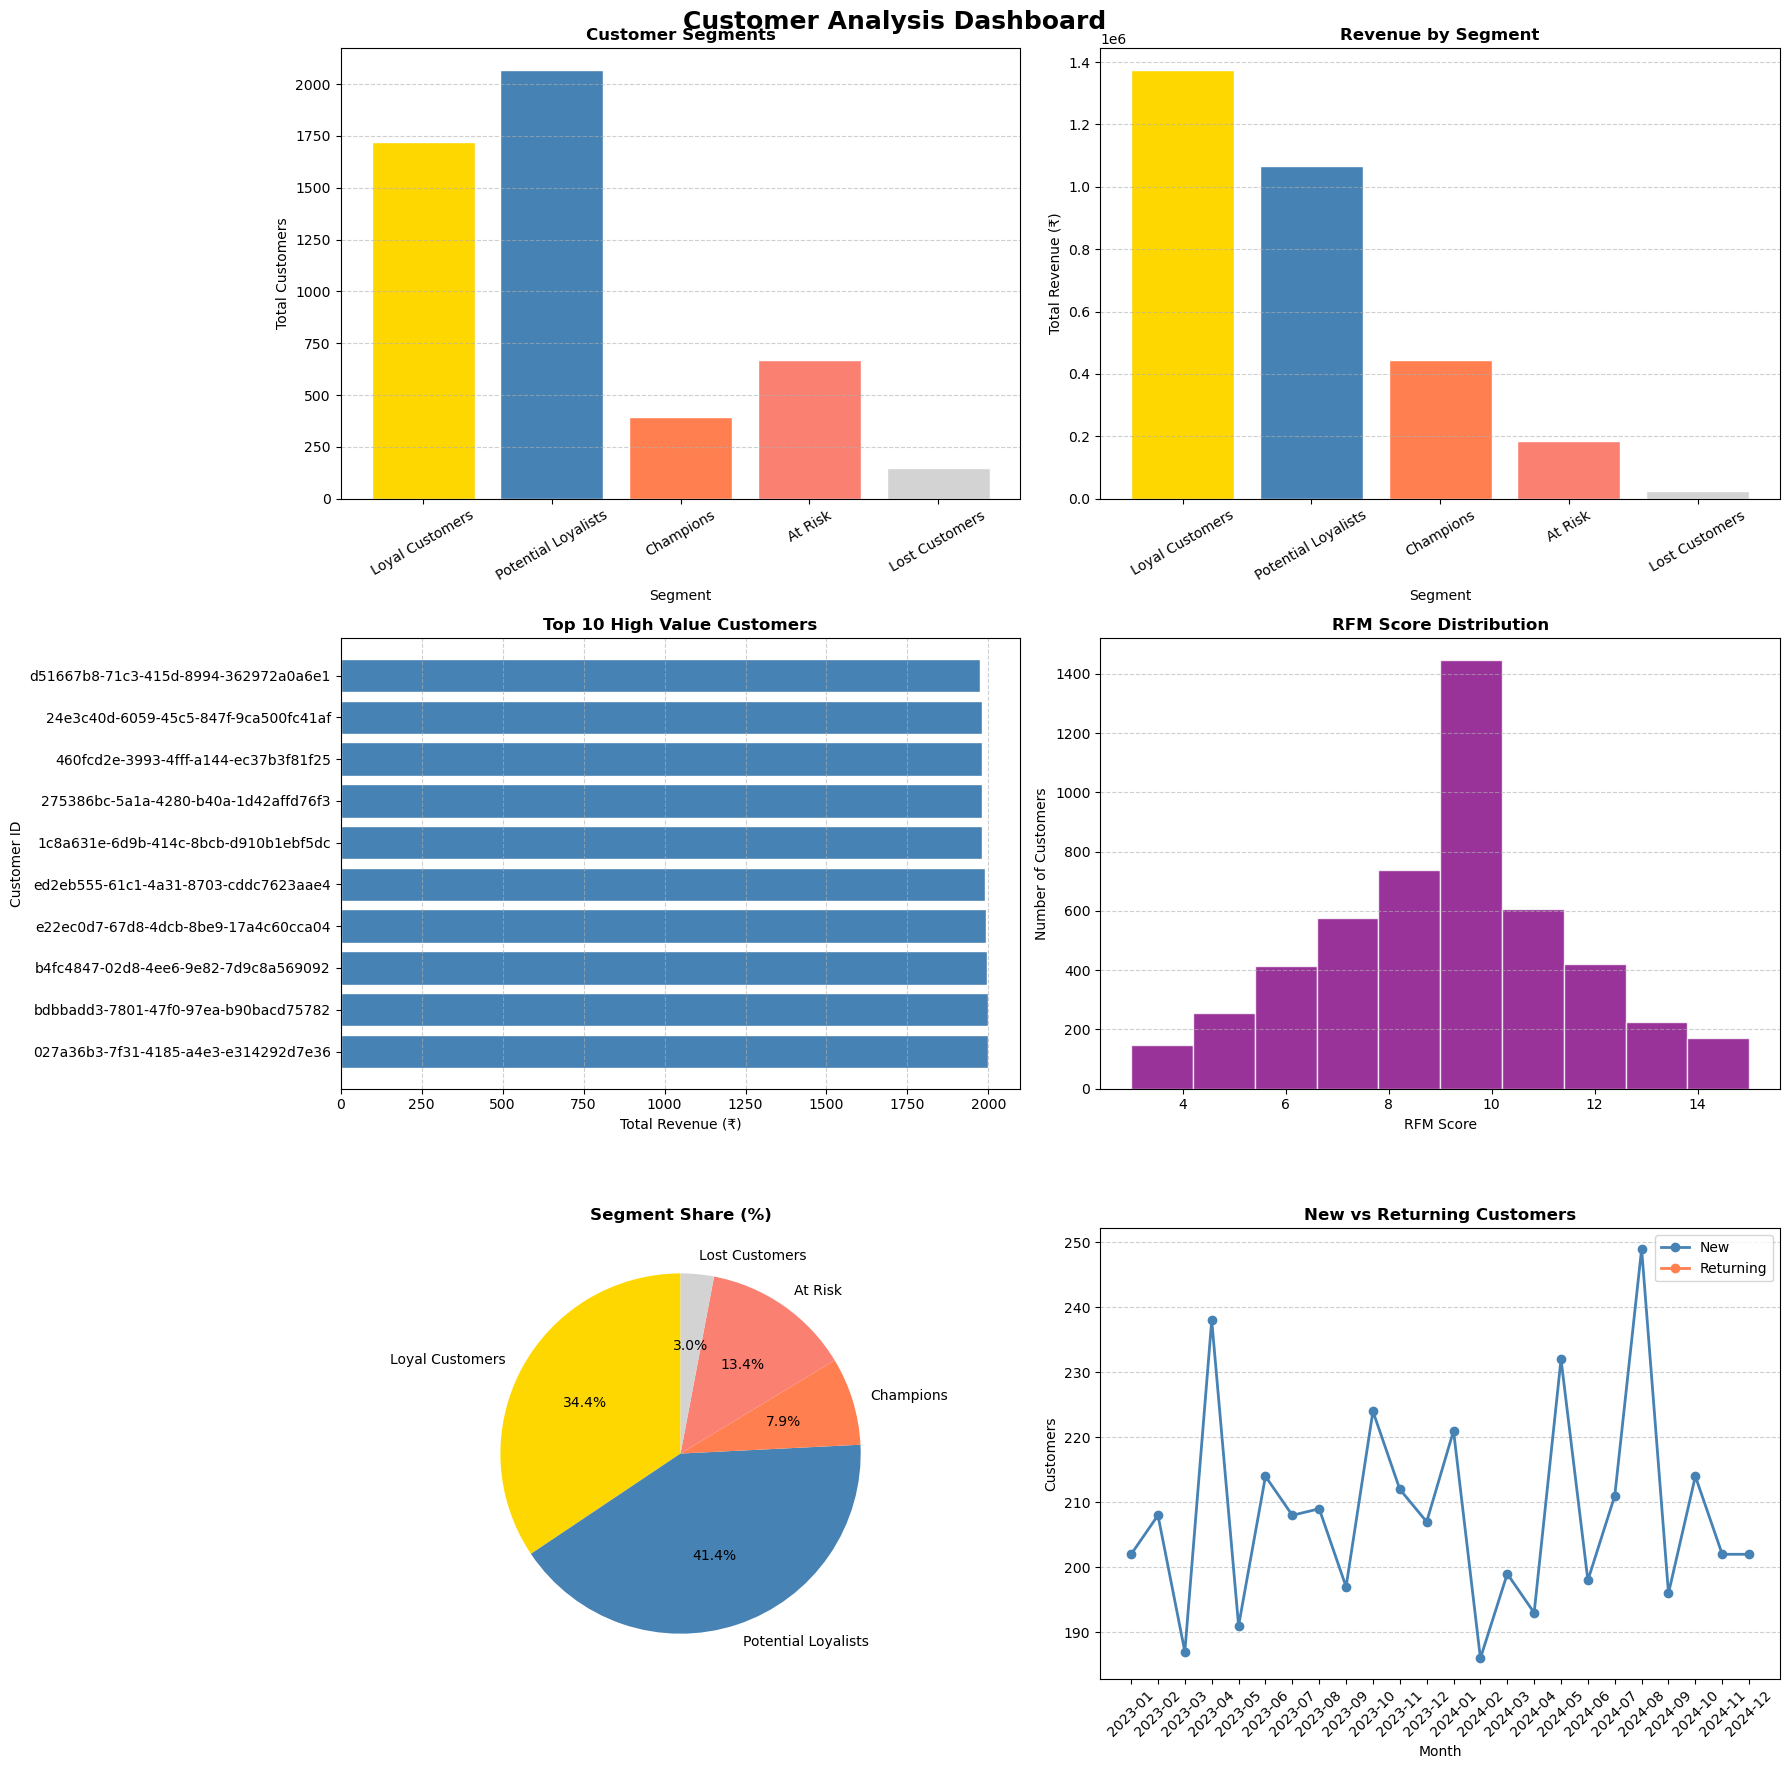

In [196]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Customer Analysis Dashboard',
             fontsize=18, fontweight='bold')

# ── Chart 1 : Customer Segments ─────────────────────────
seg_colors = ['gold','steelblue','coral','salmon','lightgray']

axes[0,0].bar(segment_summary['Segment'],
              segment_summary['Total_Customers'],
              color=seg_colors, edgecolor='white')
axes[0,0].set_title('Customer Segments',   fontweight='bold')
axes[0,0].set_xlabel('Segment')
axes[0,0].set_ylabel('Total Customers')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(axis='y', linestyle='--',   alpha=0.6)

# ── Chart 2 : Revenue by Segment ────────────────────────
axes[0,1].bar(segment_summary['Segment'],
              segment_summary['Total_Revenue'],
              color=seg_colors, edgecolor='white')
axes[0,1].set_title('Revenue by Segment',  fontweight='bold')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Total Revenue (₹)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].grid(axis='y', linestyle='--',   alpha=0.6)

# ── Chart 3 : Top 10 High Value Customers ───────────────
axes[1,0].barh(high_value['customer_id'].astype(str),
               high_value['Total_Revenue'],
               color='steelblue', edgecolor='white')
axes[1,0].set_title('Top 10 High Value Customers', fontweight='bold')
axes[1,0].set_xlabel('Total Revenue (₹)')
axes[1,0].set_ylabel('Customer ID')
axes[1,0].grid(axis='x', linestyle='--',   alpha=0.6)

# ── Chart 4 : RFM Score Distribution ────────────────────
axes[1,1].hist(rfm['RFM_Score'], bins=10,
               color='purple', edgecolor='white', alpha=0.8)
axes[1,1].set_title('RFM Score Distribution', fontweight='bold')
axes[1,1].set_xlabel('RFM Score')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].grid(axis='y', linestyle='--',   alpha=0.6)

# ── Chart 5 : Segment Pie Chart ─────────────────────────
axes[2,0].pie(segment_summary['Total_Customers'],
              labels   = segment_summary['Segment'],
              autopct  = '%1.1f%%',
              colors   = seg_colors,
              startangle = 90)
axes[2,0].set_title('Segment Share (%)',   fontweight='bold')

# ── Chart 6 : New vs Returning Customers ────────────────
new_c = retention[retention['customer_type']=='New Customer']
ret_c = retention[retention['customer_type']=='Returning Customer']

axes[2,1].plot(new_c['year_month'].astype(str),
               new_c['count'],
               label='New',       color='steelblue',
               marker='o',        linewidth=2)
axes[2,1].plot(ret_c['year_month'].astype(str),
               ret_c['count'],
               label='Returning', color='coral',
               marker='o',        linewidth=2)
axes[2,1].set_title('New vs Returning Customers', fontweight='bold')
axes[2,1].set_xlabel('Month')
axes[2,1].set_ylabel('Customers')
axes[2,1].tick_params(axis='x',  rotation=45)
axes[2,1].legend()
axes[2,1].grid(axis='y', linestyle='--',  alpha=0.6)

plt.tight_layout()
plt.show()

In [203]:
####1. Sales Performance by Region  ####
regional_sales = df.groupby('region').agg(
    Total_Sales      = ('total_price', 'sum'),
    Total_Orders     = ('order_id',    'count'),
    Total_Quantity   = ('quantity',    'sum'),
    Avg_Order_Value  = ('total_price', 'mean'),
    Unique_Customers = ('customer_id', 'nunique')
).reset_index().sort_values('Total_Sales', ascending=False)

# revenue share %
regional_sales['Revenue_Share_%'] = (
    regional_sales['Total_Sales'] / 
    regional_sales['Total_Sales'].sum() * 100).round(2)

print("="*80)
print("        SALES PERFORMANCE BY REGION")
print("="*80)
print(regional_sales)

####2. Top & Underperforming Regions ####
# ── Top Performing ──────────────────────────────────────
top_regions  = regional_sales.head(3)
print("\n=== TOP PERFORMING REGIONS ===")
print(top_regions[['region','Total_Sales',
                   'Total_Orders','Revenue_Share_%']])

# ── Underperforming ─────────────────────────────────────
low_regions  = regional_sales.tail(3)
print("\n=== UNDERPERFORMING REGIONS ===")
print(low_regions[['region','Total_Sales',
                   'Total_Orders','Revenue_Share_%']])

# ── Above / Below Average ───────────────────────────────
avg_sales    = regional_sales['Total_Sales'].mean()

regional_sales['Performance'] = np.where(
    regional_sales['Total_Sales'] >= avg_sales,
    'Above Average ✅',
    'Below Average ❌')

print(f"\n Average Regional Sales : ₹{avg_sales:,.2f}")
print(regional_sales[['region','Total_Sales','Performance']])

####3. Regional Trends Over Time  #####
# ── Monthly Sales by Region ─────────────────────────────
df['year_month'] = df['order_date'].dt.to_period('M')

regional_trend = df.groupby(
    ['year_month','region'])['total_price']\
    .sum().reset_index()
regional_trend.columns = ['year_month','region','Total_Sales']
regional_trend['year_month'] = regional_trend['year_month'].astype(str)

print("\n=== MONTHLY REGIONAL TREND ===")
print(regional_trend.head(10))

# ── Yearly Sales by Region ──────────────────────────────
df['year'] = df['order_date'].dt.year

yearly_regional = df.groupby(
    ['year','region'])['total_price']\
    .sum().reset_index()
yearly_regional.columns = ['year','region','Total_Sales']

# ── YoY Growth by Region ────────────────────────────────
yearly_regional['YoY_Growth_%'] = yearly_regional.groupby(
    'region')['Total_Sales'].pct_change() * 100

print("\n=== YEARLY REGIONAL TREND WITH GROWTH ===")
print(yearly_regional)

#### 4. Customer Distribution by Region ####
customer_region = df.groupby('region').agg(
    Unique_Customers  = ('customer_id', 'nunique'),
    Repeat_Customers  = ('customer_id', lambda x: 
                         x[df.loc[x.index,'customer_id']
                         .duplicated()].nunique()),
    Avg_Revenue_Cust  = ('total_price', 'sum')
).reset_index()

# avg revenue per customer
customer_region['Avg_Revenue_Cust'] = (
    customer_region['Avg_Revenue_Cust'] / 
    customer_region['Unique_Customers']).round(2)

# customer share %
customer_region['Customer_Share_%'] = (
    customer_region['Unique_Customers'] / 
    customer_region['Unique_Customers'].sum() * 100).round(2)

print("\n=== CUSTOMER DISTRIBUTION BY REGION ===")
print(customer_region)

####5. Regional Summary Print ####
print("="*50)
print("       REGIONAL INSIGHTS SUMMARY")
print("="*50)
print(f"\n Total Regions         : {regional_sales['region'].nunique()}")
print(f" Best Region           : {regional_sales.iloc[0]['region']}")
print(f" Best Region Sales     : ₹{regional_sales.iloc[0]['Total_Sales']:,.2f}")
print(f" Worst Region          : {regional_sales.iloc[-1]['region']}")
print(f" Worst Region Sales    : ₹{regional_sales.iloc[-1]['Total_Sales']:,.2f}")
print(f" Avg Regional Sales    : ₹{regional_sales['Total_Sales'].mean():,.2f}")
print(f" Top Region Share      : {regional_sales.iloc[0]['Revenue_Share_%']:.1f}%")

        SALES PERFORMANCE BY REGION
    region  Total_Sales  Total_Orders  Total_Quantity  Avg_Order_Value  \
2    North    640540.90          1048            2632       611.203149   
3    South    630985.94          1004            2516       628.472052   
1     East    615915.32           977            2426       630.414862   
4     West    611990.45          1018            2468       601.169401   
0  Central    594725.05           953            2384       624.055666   

   Unique_Customers  Revenue_Share_%  
2              1048            20.70  
3              1004            20.39  
1               977            19.91  
4              1018            19.78  
0               953            19.22  

=== TOP PERFORMING REGIONS ===
  region  Total_Sales  Total_Orders  Revenue_Share_%
2  North    640540.90          1048            20.70
3  South    630985.94          1004            20.39
1   East    615915.32           977            19.91

=== UNDERPERFORMING REGIONS ===
    regi

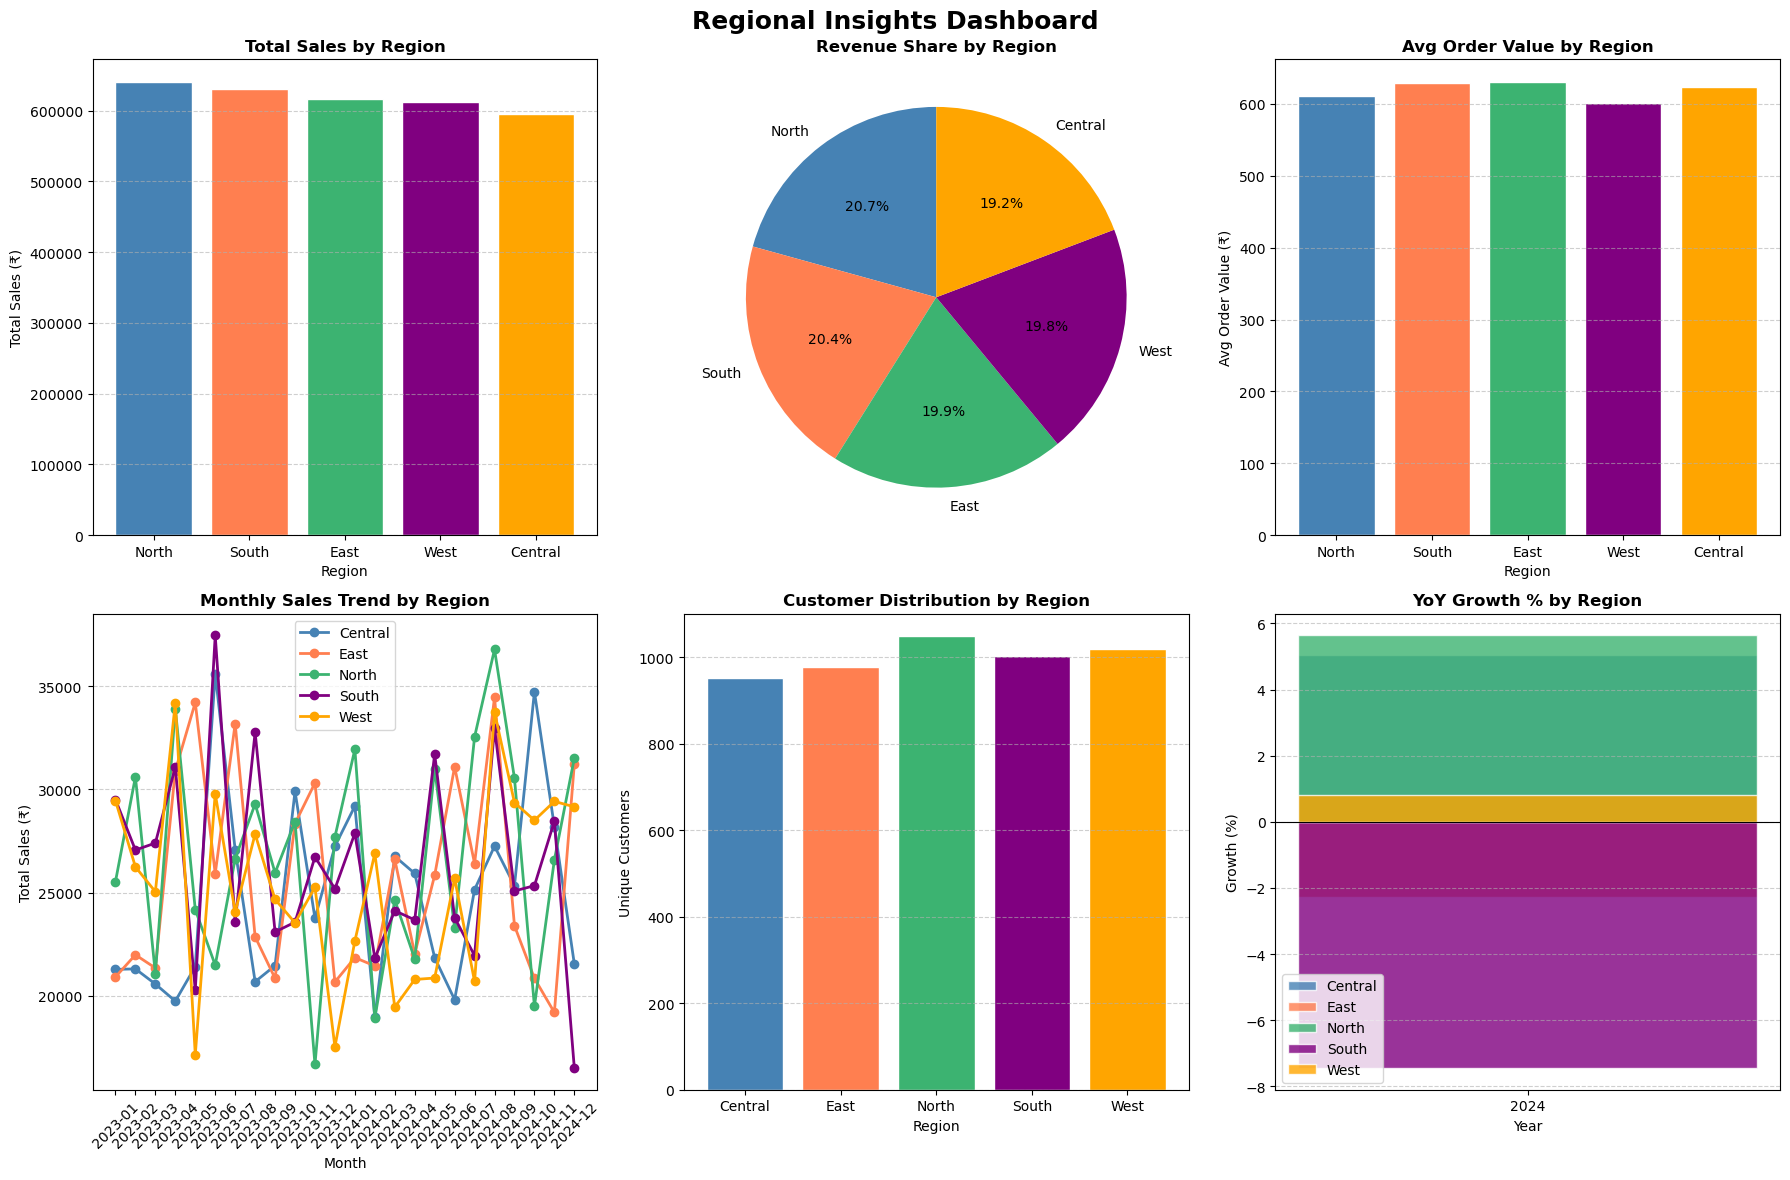

In [204]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Regional Insights Dashboard',
             fontsize=18, fontweight='bold')

reg_colors = ['steelblue','coral','mediumseagreen',
              'purple','orange','salmon']

# ── Chart 1 : Sales by Region (Bar) ─────────────────────
axes[0,0].bar(regional_sales['region'],
              regional_sales['Total_Sales'],
              color=reg_colors[:len(regional_sales)],
              edgecolor='white')
axes[0,0].set_title('Total Sales by Region',  fontweight='bold')
axes[0,0].set_xlabel('Region')
axes[0,0].set_ylabel('Total Sales (₹)')
axes[0,0].grid(axis='y', linestyle='--',      alpha=0.6)

# ── Chart 2 : Revenue Share % (Pie) ─────────────────────
axes[0,1].pie(regional_sales['Revenue_Share_%'],
              labels    = regional_sales['region'],
              autopct   = '%1.1f%%',
              colors    = reg_colors[:len(regional_sales)],
              startangle= 90)
axes[0,1].set_title('Revenue Share by Region', fontweight='bold')

# ── Chart 3 : Avg Order Value by Region ─────────────────
axes[0,2].bar(regional_sales['region'],
              regional_sales['Avg_Order_Value'],
              color=reg_colors[:len(regional_sales)],
              edgecolor='white')
axes[0,2].set_title('Avg Order Value by Region', fontweight='bold')
axes[0,2].set_xlabel('Region')
axes[0,2].set_ylabel('Avg Order Value (₹)')
axes[0,2].grid(axis='y', linestyle='--',         alpha=0.6)

# ── Chart 4 : Monthly Trend by Region (Line) ────────────
for i, region in enumerate(regional_trend['region'].unique()):
    data = regional_trend[regional_trend['region'] == region]
    axes[1,0].plot(data['year_month'], data['Total_Sales'],
                   label=region, color=reg_colors[i],
                   marker='o',   linewidth=2)
axes[1,0].set_title('Monthly Sales Trend by Region', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Total Sales (₹)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()
axes[1,0].grid(axis='y', linestyle='--',            alpha=0.6)

# ── Chart 5 : Customer Distribution (Bar) ───────────────
axes[1,1].bar(customer_region['region'],
              customer_region['Unique_Customers'],
              color=reg_colors[:len(customer_region)],
              edgecolor='white')
axes[1,1].set_title('Customer Distribution by Region', fontweight='bold')
axes[1,1].set_xlabel('Region')
axes[1,1].set_ylabel('Unique Customers')
axes[1,1].grid(axis='y', linestyle='--',             alpha=0.6)

# ── Chart 6 : YoY Growth by Region (Bar) ────────────────
yoy = yearly_regional.dropna(subset=['YoY_Growth_%'])
for i, region in enumerate(yoy['region'].unique()):
    data   = yoy[yoy['region'] == region]
    x      = np.arange(len(data))
    axes[1,2].bar(data['year'].astype(str),
                  data['YoY_Growth_%'],
                  label=region,
                  color=reg_colors[i],
                  alpha=0.8,
                  edgecolor='white')
axes[1,2].axhline(y=0, color='black', linewidth=0.8)
axes[1,2].set_title('YoY Growth % by Region', fontweight='bold')
axes[1,2].set_xlabel('Year')
axes[1,2].set_ylabel('Growth (%)')
axes[1,2].legend()
axes[1,2].grid(axis='y', linestyle='--',      alpha=0.6)

plt.tight_layout()
plt.show()

    PAYMENT METHOD USAGE DISTRIBUTION
     payment_method  Total_Orders  Total_Revenue  Unique_Customers  \
3       Net Banking          1033      654160.39              1033   
0  Cash on Delivery          1014      648767.20              1014   
2        Debit Card           990      598150.13               990   
1       Credit Card           982      599329.14               982   
4            Wallet           981      593750.80               981   

   Avg_Order_Value  Order_Share_%  Revenue_Share_%  
3       633.262720          20.66            21.14  
0       639.809862          20.28            20.97  
2       604.192051          19.80            19.33  
1       610.314807          19.64            19.37  
4       605.250561          19.62            19.19  

=== ORDER VALUE STATS BY PAYMENT METHOD ===
     payment_method        Mean   Median    Min      Max     Std_Dev
0  Cash on Delivery  639.809862  486.575  10.04  1997.60  496.778263
3       Net Banking  633.262720  479.280

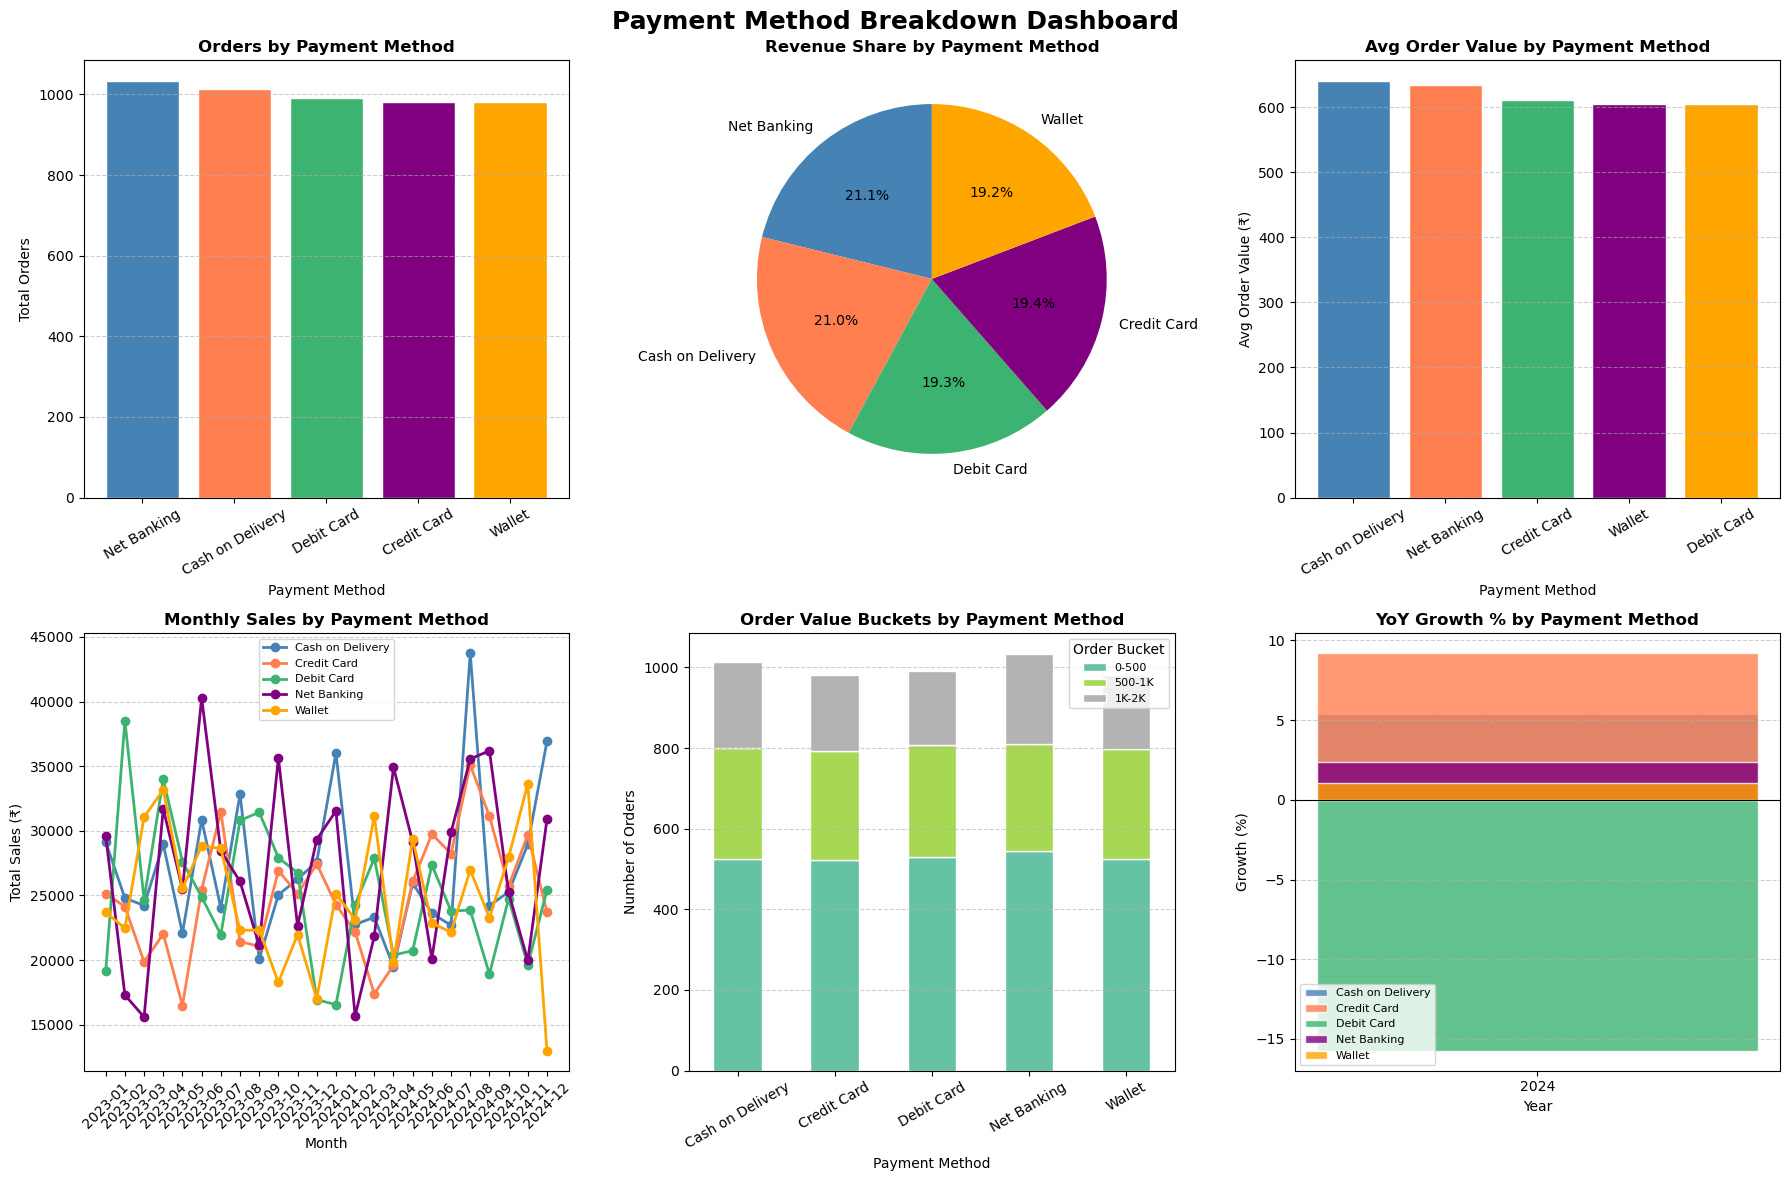

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ensure correct types
df['order_date']  = pd.to_datetime(df['order_date'])
df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce')
df['year_month']  = df['order_date'].dt.to_period('M')
df['year']        = df['order_date'].dt.year

#1. Payment Method Usage Distribution
payment_dist = df.groupby('payment_method').agg(
    Total_Orders     = ('order_id',    'count'),
    Total_Revenue    = ('total_price', 'sum'),
    Unique_Customers = ('customer_id', 'nunique'),
    Avg_Order_Value  = ('total_price', 'mean')
).reset_index().sort_values('Total_Orders', ascending=False)

# order & revenue share %
payment_dist['Order_Share_%']   = (
    payment_dist['Total_Orders'] /
    payment_dist['Total_Orders'].sum() * 100).round(2)

payment_dist['Revenue_Share_%'] = (
    payment_dist['Total_Revenue'] /
    payment_dist['Total_Revenue'].sum() * 100).round(2)

print("="*60)
print("    PAYMENT METHOD USAGE DISTRIBUTION")
print("="*60)
print(payment_dist)

#2. Correlation Between Payment Method & Order Value
# ── Stats per Payment Method ─────────────────────────────
print("\n=== ORDER VALUE STATS BY PAYMENT METHOD ===")
aov_payment = df.groupby('payment_method')['total_price']\
                .agg(['mean','median','min','max','std'])\
                .reset_index()
aov_payment.columns = ['payment_method','Mean',
                        'Median','Min','Max','Std_Dev']
aov_payment = aov_payment.sort_values('Mean', ascending=False)
print(aov_payment)

# ── Order Value Buckets ──────────────────────────────────
df['order_bucket'] = pd.cut(df['total_price'],
    bins   = [0, 500, 1000, 2000, 5000, np.inf],
    labels = ['0-500','500-1K','1K-2K','2K-5K','5K+'])

bucket_pivot = df.groupby(
    ['payment_method','order_bucket'],
    observed=True)['order_id']\
    .count().unstack(fill_value=0)

print("\n=== ORDER VALUE BUCKETS BY PAYMENT METHOD ===")
print(bucket_pivot)

# ── Correlation Score ────────────────────────────────────
# encode payment method as numeric
df['payment_encoded'] = df['payment_method'].astype('category').cat.codes
correlation = df[['payment_encoded','total_price']].corr()
print("\n=== CORRELATION : PAYMENT METHOD vs ORDER VALUE ===")
print(correlation)

##3. Payment Method Trends Over Time
# ── Monthly Trend ────────────────────────────────────────
monthly_payment = df.groupby(
    ['year_month','payment_method'])['total_price']\
    .sum().reset_index()
monthly_payment.columns = ['year_month',
                           'payment_method','Total_Sales']
monthly_payment['year_month'] = monthly_payment[
                                'year_month'].astype(str)

# ── Yearly Trend ─────────────────────────────────────────
yearly_payment = df.groupby(
    ['year','payment_method'])['total_price']\
    .sum().reset_index()
yearly_payment.columns = ['year',
                          'payment_method','Total_Sales']

# ── YoY Growth ───────────────────────────────────────────
yearly_payment['YoY_Growth_%'] = yearly_payment\
    .groupby('payment_method')['Total_Sales']\
    .pct_change() * 100

print("\n=== MONTHLY PAYMENT TREND (first 10 rows) ===")
print(monthly_payment.head(10))

print("\n=== YEARLY PAYMENT TREND WITH YoY GROWTH ===")
print(yearly_payment)

#4. Payment Summary Print
print("="*50)
print("      PAYMENT METHOD SUMMARY")
print("="*50)
print(f"\n Total Payment Methods  : "
      f"{payment_dist['payment_method'].nunique()}")
print(f" Most Used Method       : "
      f"{payment_dist.iloc[0]['payment_method']}")
print(f" Most Used Order Share  : "
      f"{payment_dist.iloc[0]['Order_Share_%']:.1f}%")
print(f" Highest Avg Order      : "
      f"{aov_payment.iloc[0]['payment_method']}")
print(f" Highest Avg Value      : "
      f"₹{aov_payment.iloc[0]['Mean']:,.2f}")
print(f" Least Used Method      : "
      f"{payment_dist.iloc[-1]['payment_method']}")
print(f" Least Used Share       : "
      f"{payment_dist.iloc[-1]['Order_Share_%']:.1f}%")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Payment Method Breakdown Dashboard',
              fontsize=18, fontweight='bold')

pay_colors = ['steelblue','coral','mediumseagreen',
              'purple','orange']

# ── Chart 1 : Orders by Payment Method (Bar) ────────────
axes[0,0].bar(payment_dist['payment_method'],
              payment_dist['Total_Orders'],
              color=pay_colors, edgecolor='white')
axes[0,0].set_title('Orders by Payment Method',
                     fontweight='bold')
axes[0,0].set_xlabel('Payment Method')
axes[0,0].set_ylabel('Total Orders')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.6)

# ── Chart 2 : Revenue Share (Pie) ───────────────────────
axes[0,1].pie(payment_dist['Revenue_Share_%'],
              labels     = payment_dist['payment_method'],
              autopct    = '%1.1f%%',
              colors     = pay_colors,
              startangle = 90)
axes[0,1].set_title('Revenue Share by Payment Method',
                     fontweight='bold')

# ── Chart 3 : Avg Order Value (Bar) ─────────────────────
axes[0,2].bar(aov_payment['payment_method'],
              aov_payment['Mean'],
              color=pay_colors, edgecolor='white')
axes[0,2].set_title('Avg Order Value by Payment Method',
                     fontweight='bold')
axes[0,2].set_xlabel('Payment Method')
axes[0,2].set_ylabel('Avg Order Value (₹)')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].grid(axis='y', linestyle='--', alpha=0.6)

# ── Chart 4 : Monthly Trend (Line) ──────────────────────
for i, method in enumerate(
        monthly_payment['payment_method'].unique()):
    data = monthly_payment[
           monthly_payment['payment_method'] == method]
    axes[1,0].plot(data['year_month'],
                   data['Total_Sales'],
                   label   = method,
                   color   = pay_colors[i],
                   marker  = 'o',
                   linewidth = 2)
axes[1,0].set_title('Monthly Sales by Payment Method',
                     fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Total Sales (₹)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(fontsize=8)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.6)

# ── Chart 5 : Order Value Buckets (Stacked Bar) ─────────
bucket_pivot.plot(kind    = 'bar',
                  stacked = True,
                  ax      = axes[1,1],
                  colormap= 'Set2',
                  edgecolor='white')
axes[1,1].set_title('Order Value Buckets by Payment Method',
                     fontweight='bold')
axes[1,1].set_xlabel('Payment Method')
axes[1,1].set_ylabel('Number of Orders')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(title='Order Bucket', fontsize=8)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.6)

# ── Chart 6 : YoY Growth (Bar) ──────────────────────────
yoy = yearly_payment.dropna(subset=['YoY_Growth_%'])
for i, method in enumerate(
        yoy['payment_method'].unique()):
    data = yoy[yoy['payment_method'] == method]
    axes[1,2].bar(data['year'].astype(str),
                  data['YoY_Growth_%'],
                  label     = method,
                  color     = pay_colors[i],
                  alpha     = 0.8,
                  edgecolor = 'white')
axes[1,2].axhline(y=0, color='black', linewidth=0.8)
axes[1,2].set_title('YoY Growth % by Payment Method',
                     fontweight='bold')
axes[1,2].set_xlabel('Year')
axes[1,2].set_ylabel('Growth (%)')
axes[1,2].legend(fontsize=8)
axes[1,2].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()